# K-Prototypes Clustering — Spotify Liked Songs

This notebook applies the **K-Prototypes** algorithm to cluster ~1,565 songs from a personal Spotify Liked Songs library into thematic groups. 

K-Prototypes is chosen over K-Means because the dataset contains a mix of **continuous** audio features (e.g., danceability, energy) and **categorical** features (e.g., musical key, mode, instrumentalness). K-Means relies on Euclidean distance, which is not meaningful for categorical data; K-Prototypes uses a hybrid dissimilarity measure that handles both types natively.

**Data source:** `spotifyLibrary_cleaned.csv` — preprocessed and MinMax-scaled output from the Spotify Data Cleaning notebook.

## 1. Setup & Library Imports

Import all required libraries. If `kmodes` is not installed in the current environment it will be installed automatically. `kmodes` provides the `KPrototypes` class, which extends the K-Means framework with support for categorical features using Huang's dissimilarity metric.

In [1]:
import sys
import subprocess

try:
    from kmodes.kprototypes import KPrototypes
except ImportError:
    print("kmodes not found — installing...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'kmodes', '--quiet'])
    from kmodes.kprototypes import KPrototypes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid')

print("All libraries imported successfully.")
print(f"  pandas {pd.__version__}  |  numpy {np.__version__}  |  seaborn {sns.__version__}")

kmodes not found — installing...
All libraries imported successfully.
  pandas 3.0.2  |  numpy 2.4.4  |  seaborn 0.13.2


## 2. Load & Inspect the Cleaned Dataset

Load `spotifyLibrary_cleaned.csv`. This file was produced by the Data Cleaning notebook. It contains **11 audio features** per track — all numeric — with continuous features already MinMax-scaled to [0, 1]. No missing values are expected.

In [17]:
df = pd.read_csv('../data_files/spotifyLibrary_cleaned.csv')

print(f"Dataset shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"\nColumn dtypes:")
print(df.dtypes.to_string())
df.head()

Dataset shape  : 1,565 rows × 11 columns
Missing values : 0

Column dtypes:
danceability        float64
energy              float64
key                   int64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness      int64
liveness            float64
valence             float64
tempo               float64
duration_min        float64


,danceability,energy,key,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
0,0.696233,0.641808,4,0,0.429519,0.054106,0,0.143758,0.586742,0.331528,0.329403
1,0.782503,0.654237,1,1,0.521246,0.152519,0,0.234267,0.496539,0.670667,0.269764
2,0.534629,0.366102,10,0,0.032564,0.080696,0,0.251718,0.138871,0.370424,0.242092
3,0.919806,0.616949,6,0,0.393466,0.002568,0,0.186067,0.711559,0.552147,0.262229
4,0.699878,0.803390,1,1,0.321676,0.253158,0,0.528165,0.627648,0.262973,0.360816


## 3. Feature Identification — Continuous vs Categorical

K-Prototypes requires explicitly specifying which columns are **categorical** so it can apply the correct distance measure to each type:

| Type | Features | Notes |
|------|----------|-------|
| **Continuous** | danceability, energy, speechiness, acousticness, liveness, valence, tempo, duration_min | Float, MinMax-scaled [0,1] — Euclidean distance |
| **Categorical** | `key` (0–11), `mode` (0=minor, 1=major), `instrumentalness` (0=vocal, 1=instrumental) | Integer-encoded nominals — Hamming-style dissimilarity |

In [18]:
CATEGORICAL_COLS = ['key', 'mode', 'instrumentalness']
CONTINUOUS_COLS  = [c for c in df.columns
                    if c not in CATEGORICAL_COLS + ['id', 'songName']]
CAT_INDICES      = [list(df.columns).index(c) for c in CATEGORICAL_COLS]

print(f"Continuous features  ({len(CONTINUOUS_COLS)}): {CONTINUOUS_COLS}")
print(f"Categorical features ({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}")
print(f"Categorical column indices : {CAT_INDICES}")
print()
for col in CATEGORICAL_COLS:
    print(f"  {col:20s} — unique values: {sorted(df[col].unique())}")

Continuous features  (8): ['danceability', 'energy', 'speechiness', 'acousticness', 'liveness', 'valence', 'tempo', 'duration_min']
Categorical features (3): ['key', 'mode', 'instrumentalness']
Categorical column indices : [2, 3, 6]

  key                  — unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)]
  mode                 — unique values: [np.int64(0), np.int64(1)]
  instrumentalness     — unique values: [np.int64(0), np.int64(1)]


## 4. Prepare Data Matrix for K-Prototypes

K-Prototypes accepts a single NumPy array. Categorical columns are cast to **strings** so the library can distinguish them from continuous float columns during the dissimilarity computation. The original `df` is left unchanged for later visualisation.

In [20]:
# Drop id/songName — not features, not passed to KPrototypes
X = df.drop(columns=[c for c in ['id', 'songName'] if c in df.columns]).copy()
for col in CATEGORICAL_COLS:
    X[col] = X[col].astype(str)

X_matrix = X.to_numpy()

print(f"X_matrix shape : {X_matrix.shape}")
print(f"Array dtype    : {X_matrix.dtype}  (object — mixed types expected)")
print(f"\nSample row [0] : {X_matrix[0]}")

X_matrix shape : (1565, 11)
Array dtype    : object  (object — mixed types expected)

Sample row [0] : [0.6962332928311058 0.6418079096045198 '4' '0' 0.4295188252104465
 0.0541058047648532 '0' 0.1437576513332943 0.5867421858611285
 0.331528196405568 0.3294034414090133]


## 5. Elbow Method — Selecting the Optimal Number of Clusters

Run K-Prototypes for k = 2 through 12 and record the **total cost** (sum of intra-cluster dissimilarities). Plot cost vs k and look for the "elbow" — the inflection point where additional clusters yield diminishing reduction in cost.

Total cost (intra-cluster dissimilarity)
"Cost" here means how different the players within each cluster are from each other. Lower cost = players within a cluster are more similar to each other = better clustering. As you add more clusters the cost always goes down — but at some point adding another cluster stops being meaningful.


- `init='Cao'` seeds centroids using Cao et al.'s method, which is more stable than random initialisation for mixed-type data.
- `n_init=1` is appropriate with Cao initialisation since it is deterministic. (Always starts from the same smart starting point (not random starting points))

Running elbow scan — fitting K-Prototypes for k = 2..12...
(Each fit may take 10–30 seconds on ~1,500 records)

  k= 2  →  cost =       510.93
  k= 3  →  cost =       471.40
  k= 4  →  cost =       437.89
  k= 5  →  cost =       409.84
  k= 6  →  cost =       395.59
  k= 7  →  cost =       384.90
  k= 8  →  cost =       372.61
  k= 9  →  cost =       358.63
  k=10  →  cost =       355.43
  k=11  →  cost =       341.19
  k=12  →  cost =       337.48


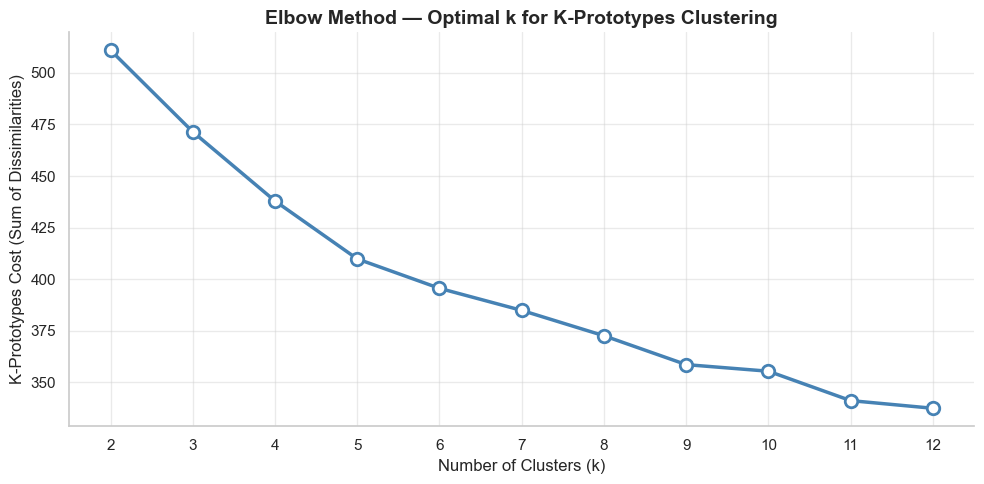


Identify the elbow: the k where the cost curve transitions from steep to flat.


In [21]:
K_RANGE = range(2, 13)
costs   = []

print("Running elbow scan — fitting K-Prototypes for k = 2..12...")
print("(Each fit may take 10–30 seconds on ~1,500 records)\n")

for k in K_RANGE:
    kp = KPrototypes(n_clusters=k, init='Cao', n_init=1, verbose=0)
    kp.fit_predict(X_matrix, categorical=CAT_INDICES)
    costs.append(kp.cost_)
    print(f"  k={k:2d}  →  cost = {kp.cost_:>12,.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(K_RANGE), costs,
        marker='o', linewidth=2.5, markersize=9,
        color='steelblue', markerfacecolor='white', markeredgewidth=2)
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('K-Prototypes Cost (Sum of Dissimilarities)', fontsize=12)
ax.set_title('Elbow Method — Optimal k for K-Prototypes Clustering',
             fontsize=14, fontweight='bold')
ax.set_xticks(list(K_RANGE))
ax.grid(True, alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig('../data_files/elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nIdentify the elbow: the k where the cost curve transitions from steep to flat.")

## 6. Fit Final K-Prototypes Model

Based on the elbow plot, **k = 7** is selected — consistent with prior analysis showing musically meaningful separability at this granularity. The final model is fit with `verbose=1` to display iteration-level convergence progress.

In [22]:
N_CLUSTERS = 7

print(f"Fitting K-Prototypes with k={N_CLUSTERS}, init='Cao'...\n")
kp_final = KPrototypes(n_clusters=N_CLUSTERS, init='Cao', n_init=1, verbose=1)
cluster_labels = kp_final.fit_predict(X_matrix, categorical=CAT_INDICES)

df['cluster'] = cluster_labels.astype(int)

print(f"\n{'='*45}")
print(f"  Final model cost : {kp_final.cost_:>14,.4f}")
print(f"  Songs clustered  : {len(cluster_labels):,}")
print(f"{'='*45}")
print(f"\nCluster sizes:")
print(df['cluster'].value_counts().sort_index().to_frame('count').to_string())

Fitting K-Prototypes with k=7, init='Cao'...

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 654, ncost: 399.4005003924717
Run: 1, iteration: 2/100, moves: 214, ncost: 393.87001912910057
Run: 1, iteration: 3/100, moves: 123, ncost: 392.10660992805145
Run: 1, iteration: 4/100, moves: 91, ncost: 390.5333845943286
Run: 1, iteration: 5/100, moves: 101, ncost: 388.56212230367845
Run: 1, iteration: 6/100, moves: 78, ncost: 387.01280829825413
Run: 1, iteration: 7/100, moves: 69, ncost: 386.1409489489751
Run: 1, iteration: 8/100, moves: 47, ncost: 385.805681348099
Run: 1, iteration: 9/100, moves: 44, ncost: 383.7150519248863
Run: 1, iteration: 10/100, moves: 76, ncost: 383.06348962411187
Run: 1, iteration: 11/100, moves: 44, ncost: 382.66674643950375
Run: 1, iteration: 12/100, moves: 37, ncost: 382.2763698199279
Run: 1, iteration: 13/100, moves: 29, ncos

## 7. Cluster Size Distribution

Inspect how many songs fall into each cluster. Roughly balanced clusters suggest the algorithm found genuinely distinct groups. Heavily imbalanced clusters may indicate k should be increased, or that a cluster represents a rare but real song archetype (e.g., highly instrumental).

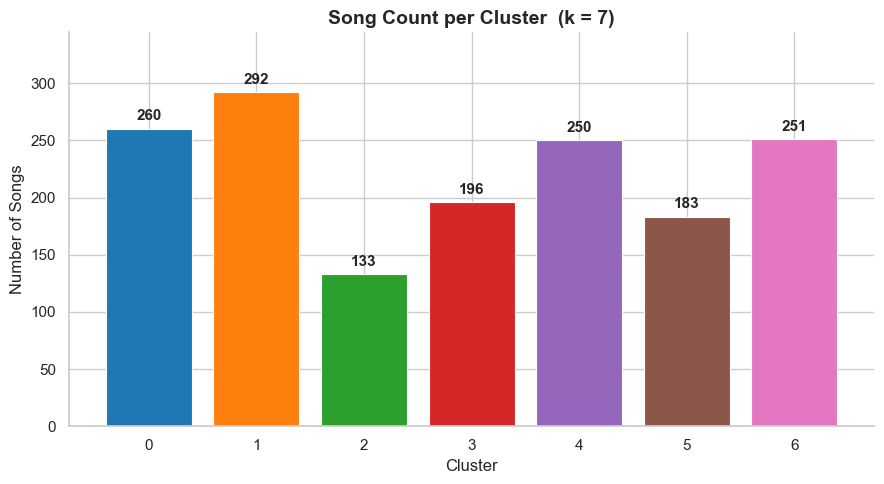

In [23]:
palette = sns.color_palette('tab10', N_CLUSTERS)
cluster_counts = df['cluster'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(cluster_counts.index, cluster_counts.values,
              color=palette, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%d', padding=4, fontsize=11, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Number of Songs', fontsize=12)
ax.set_title(f'Song Count per Cluster  (k = {N_CLUSTERS})',
             fontsize=14, fontweight='bold')
ax.set_xticks(range(N_CLUSTERS))
ax.set_ylim(0, cluster_counts.max() * 1.18)
sns.despine()
plt.tight_layout()
plt.show()

## 8. Cluster Feature Profile — Heatmap

Compute the **mean value of each continuous audio feature** within each cluster. The heatmap gives a high-level fingerprint of each cluster's musical character — for example, clusters with high energy + high danceability vs. high acousticness + low tempo.

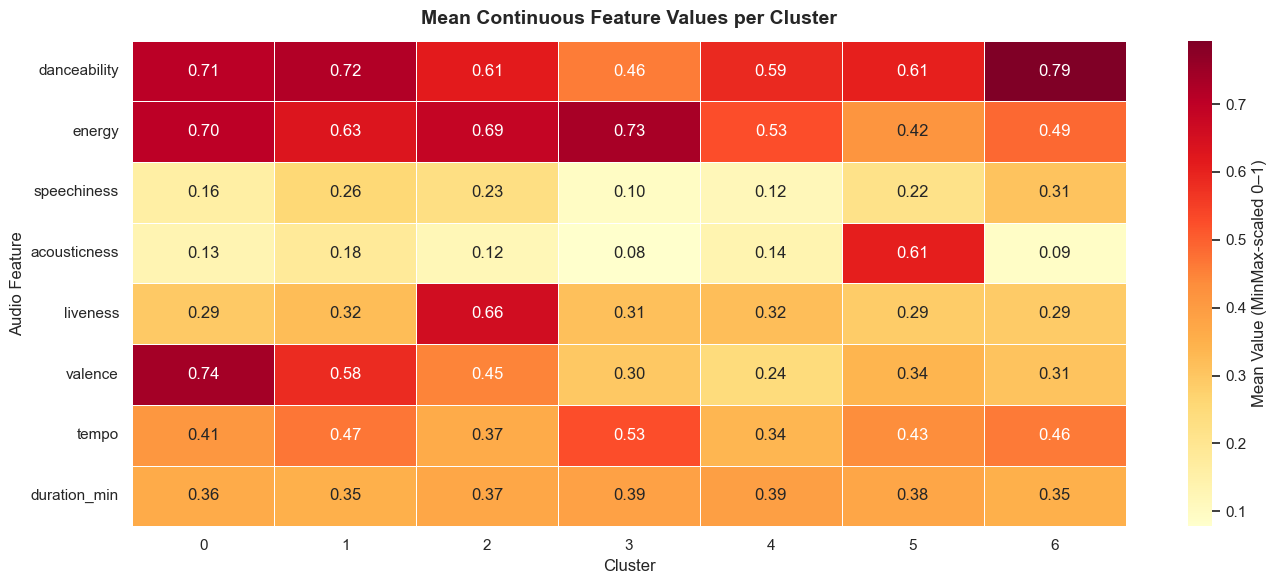

In [24]:
cluster_means = df.groupby('cluster')[CONTINUOUS_COLS].mean()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    cluster_means.T,
    annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Mean Value (MinMax-scaled 0–1)'},
    ax=ax
)
ax.set_title('Mean Continuous Feature Values per Cluster',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Audio Feature', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../data_files/cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Continuous Feature Distributions — Violin Plots

Violin plots reveal the **full distribution shape** (not just the mean) of each continuous audio feature across all clusters. This makes it easy to spot tight vs. spread distributions and to identify the defining audio characteristics of each group.

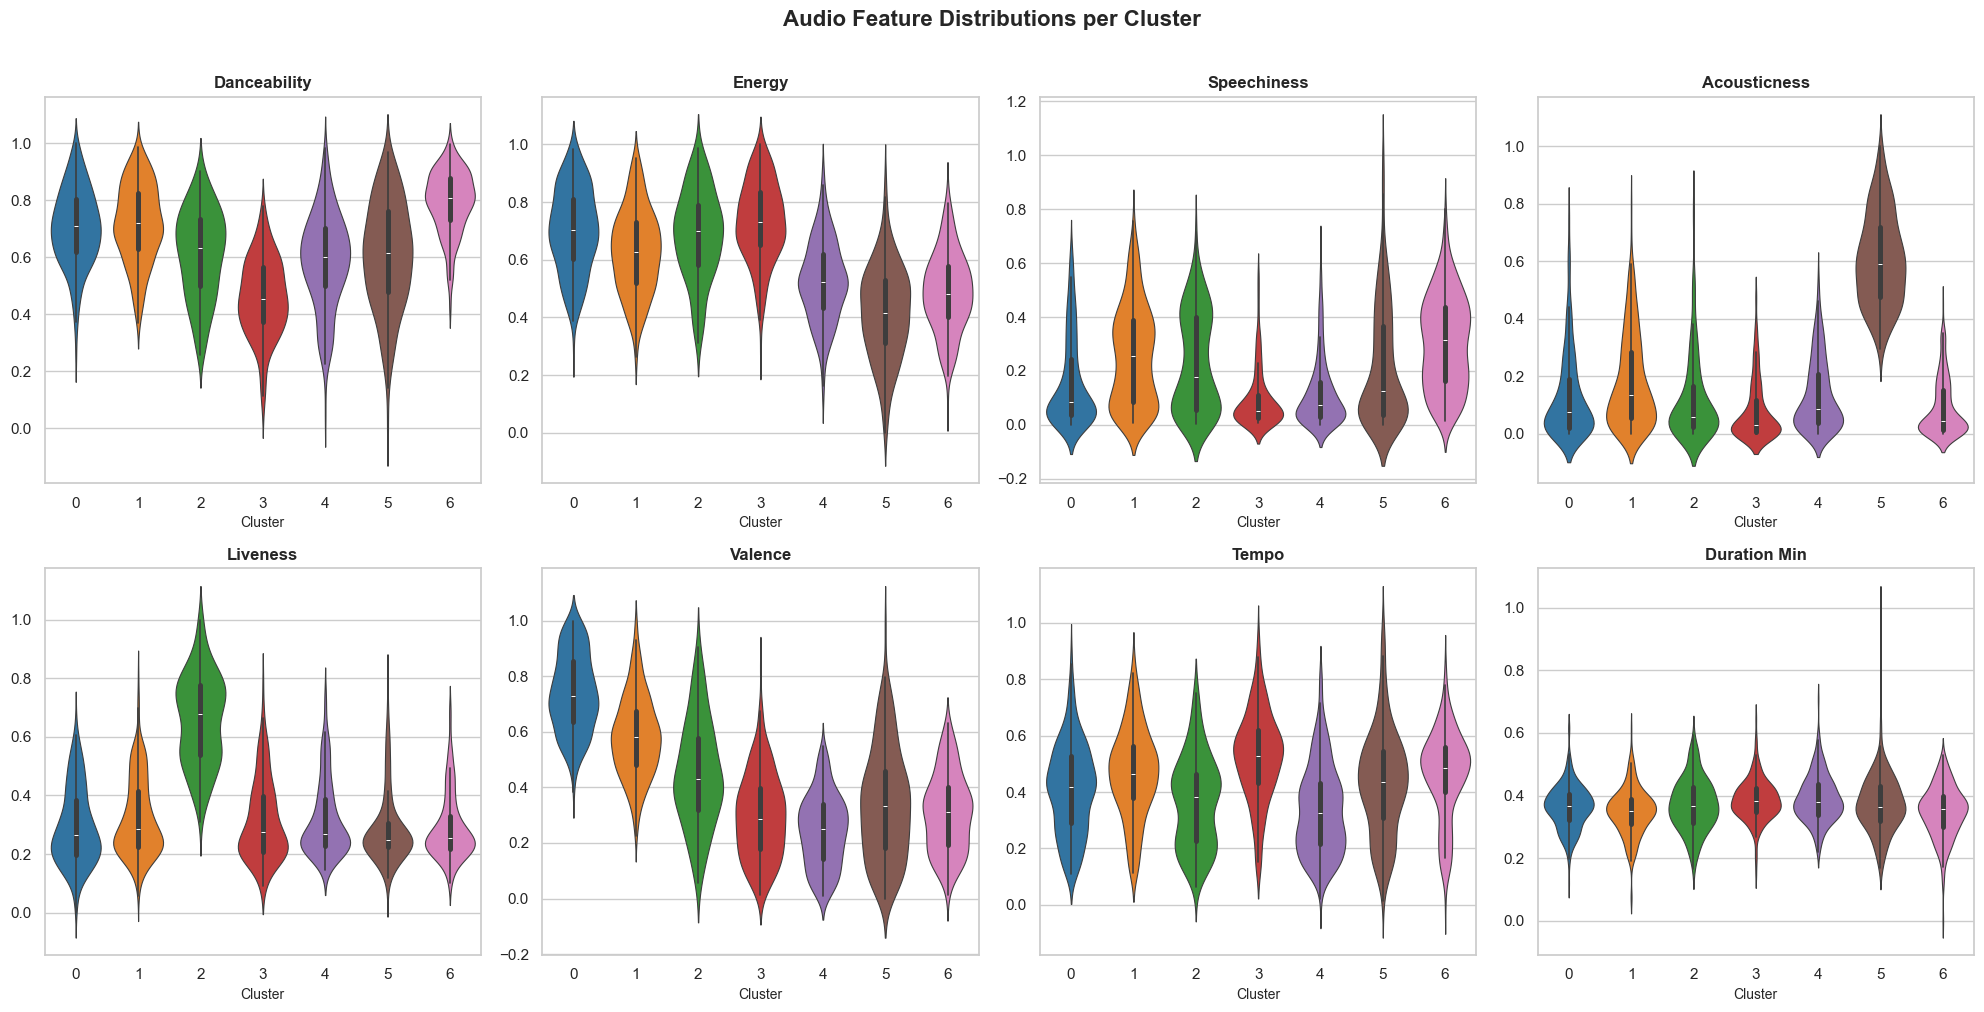

In [25]:
palette = sns.color_palette('tab10', N_CLUSTERS)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(CONTINUOUS_COLS):
    sns.violinplot(
        data=df, x='cluster', y=col,
        palette=palette, inner='box',
        linewidth=0.8, ax=axes[i]
    )
    axes[i].set_title(col.replace('_', ' ').title(),
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cluster', fontsize=10)
    axes[i].set_ylabel('')

fig.suptitle('Audio Feature Distributions per Cluster',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data_files/violin_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Categorical Feature Distributions per Cluster

Stacked bar charts show the **proportional breakdown** of each categorical feature within every cluster:

- **Key** — musical pitch class (C, C#, D … B)
- **Mode** — major (1) vs. minor (0)
- **Instrumentalness** — vocal (0) vs. instrumental (1)

These distributions highlight whether clusters gravitate toward particular tonalities, scales, or production styles.

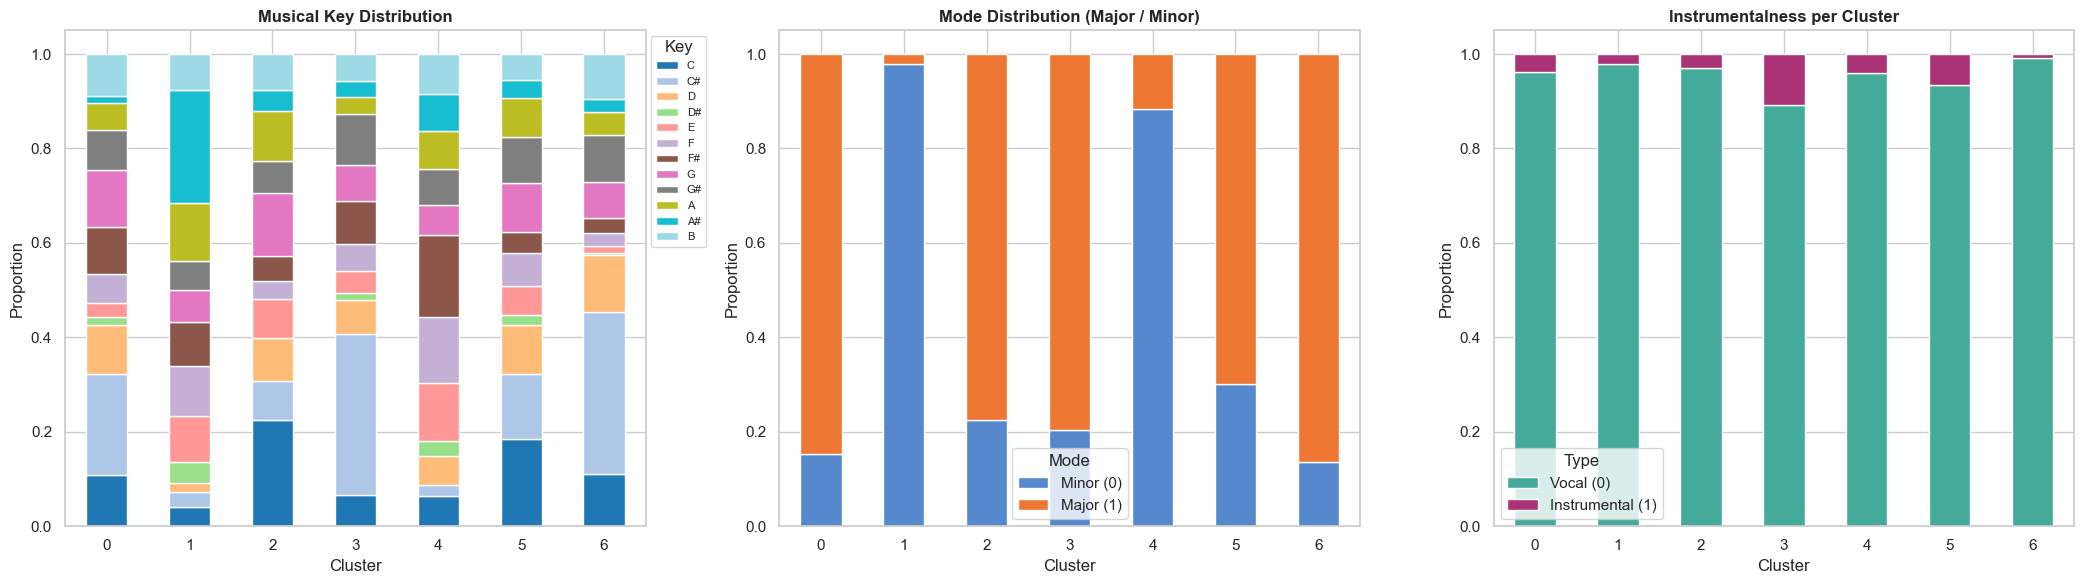

In [26]:
KEY_LABELS = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# ── Musical key ──────────────────────────────────────────────────────────────
key_pct = (df.groupby(['cluster', 'key']).size()
             .unstack(fill_value=0)
             .reindex(columns=range(12), fill_value=0)
             .apply(lambda r: r / r.sum(), axis=1))
key_pct.columns = KEY_LABELS
key_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab20')
axes[0].set_title('Musical Key Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Key', bbox_to_anchor=(1.0, 1.0), fontsize=8)

# ── Mode (major / minor) ─────────────────────────────────────────────────────
mode_pct = (df.groupby(['cluster', 'mode']).size()
              .unstack(fill_value=0))
for c in [0, 1]:
    if c not in mode_pct.columns:
        mode_pct[c] = 0
mode_pct = mode_pct[[0, 1]].apply(lambda r: r / r.sum(), axis=1)
mode_pct.columns = ['Minor (0)', 'Major (1)']
mode_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['#5588CC', '#EE7733'])
axes[1].set_title('Mode Distribution (Major / Minor)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Mode')

# ── Instrumentalness (vocal / instrumental) ───────────────────────────────────
instr_pct = (df.groupby(['cluster', 'instrumentalness']).size()
               .unstack(fill_value=0))
for c in [0, 1]:
    if c not in instr_pct.columns:
        instr_pct[c] = 0
instr_pct = instr_pct[[0, 1]].apply(lambda r: r / r.sum(), axis=1)
instr_pct.columns = ['Vocal (0)', 'Instrumental (1)']
instr_pct.plot(kind='bar', stacked=True, ax=axes[2], color=['#44AA99', '#AA3377'])
axes[2].set_title('Instrumentalness per Cluster', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Proportion')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Type')

plt.tight_layout()
plt.savefig('../data_files/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Export Clustered Dataset

Save the final DataFrame — original features plus the `cluster` label column — to `songDataKProto.csv`. This file can be used downstream for Spotify playlist creation, further qualitative analysis, or word-cloud generation per cluster.

In [27]:
# id and songName are already present in df from spotifyLibrary_cleaned.csv
output_path = '../data_files/songDataKProto.csv'
df.to_csv(output_path, index=False)

print(f'Saved to : {output_path}')
print(f'Shape    : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns  : {list(df.columns)}')
print()
df[['id', 'songName', 'cluster'] + CONTINUOUS_COLS + CATEGORICAL_COLS].head(10)

Saved to      : ../data_files/songDataKProto.csv
Shape         : 1,565 rows × 12 columns
Columns       : ['danceability', 'energy', 'key', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min', 'cluster']



,danceability,energy,key,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min,cluster
0,0.696233,0.641808,4,0,0.429519,0.054106,0,0.143758,0.586742,0.331528,0.329403,1
1,0.782503,0.654237,1,1,0.521246,0.152519,0,0.234267,0.496539,0.670667,0.269764,6
2,0.534629,0.366102,10,0,0.032564,0.080696,0,0.251718,0.138871,0.370424,0.242092,4
3,0.919806,0.616949,6,0,0.393466,0.002568,0,0.186067,0.711559,0.552147,0.262229,1
4,0.699878,0.803390,1,1,0.321676,0.253158,0,0.528165,0.627648,0.262973,0.360816,0
5,0.503038,0.687006,6,1,0.447260,0.380280,0,0.894782,0.896161,0.199238,0.215941,2
6,0.815310,0.578531,8,1,0.051963,0.017346,0,0.191739,0.429411,0.458415,0.322236,6
7,0.616039,0.564972,1,1,0.074448,0.322016,0,0.207636,0.175582,0.465012,0.362522,3
8,0.518834,0.847458,8,1,0.151764,0.015228,0,0.926985,0.359136,0.133359,0.402119,2
9,0.761847,0.731073,9,1,0.066723,0.082390,0,0.241341,0.692679,0.565072,0.217656,0


## 12. Auto-Generated Cluster Themes

Each cluster's musical character is derived programmatically by computing the **z-score** of its mean feature values relative to the global dataset distribution. The two features that deviate most from the global mean (highest absolute z-score) become the cluster's theme descriptors.

A `MANUAL_THEMES` dict is provided below — fill it in after reviewing the heatmap and violin plots to override any auto-generated label with a more expressive name (e.g., `{2: 'Late-Night R&B', 5: 'Indie Folk'}`).

Cluster Theme Summary:

   Songs                Auto Theme               Final Theme
0    260      Upbeat · High-Energy      Upbeat · High-Energy
1    292        Upbeat · Danceable        Upbeat · Danceable
2    133   Live-Feel · High-Energy   Live-Feel · High-Energy
3    196  Low-Groove · High-Energy  Low-Groove · High-Energy
4    250         Dark / Sad · Slow         Dark / Sad · Slow
5    183         Acoustic · Mellow         Acoustic · Mellow
6    251   Danceable · Wordy / Rap   Danceable · Wordy / Rap


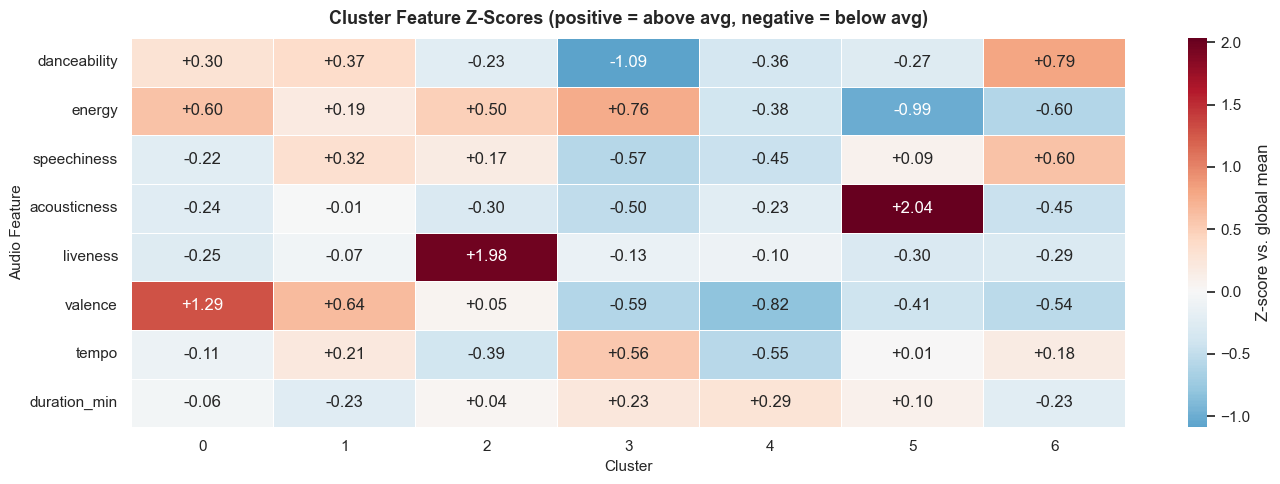

In [28]:
# Z-score of each cluster mean relative to global distribution
global_mean     = df[CONTINUOUS_COLS].mean()
global_std      = df[CONTINUOUS_COLS].std()
cluster_means   = df.groupby('cluster')[CONTINUOUS_COLS].mean()
cluster_zscores = (cluster_means - global_mean) / global_std

# Map each feature to a (high, low) descriptor pair
FEATURE_DESCRIPTORS = {
    'danceability': ('Danceable',   'Low-Groove'),
    'energy':       ('High-Energy', 'Mellow'),
    'speechiness':  ('Wordy / Rap', 'Pure Music'),
    'acousticness': ('Acoustic',    'Produced'),
    'liveness':     ('Live-Feel',   'Studio'),
    'valence':      ('Upbeat',      'Dark / Sad'),
    'tempo':        ('Fast-Paced',  'Slow'),
    'duration_min': ('Long-Form',   'Short-Form'),
}

# Build theme label from the top 2 most extreme z-scored features per cluster
AUTO_THEMES = {}
for cid in sorted(df['cluster'].unique()):
    zrow = cluster_zscores.loc[cid]
    top2 = zrow.abs().nlargest(2).index
    parts = []
    for feat in top2:
        hi, lo = FEATURE_DESCRIPTORS.get(feat, (f'High {feat}', f'Low {feat}'))
        parts.append(hi if zrow[feat] > 0 else lo)
    # Prepend 'Instrumental' if the cluster majority is non-vocal
    if df.loc[df['cluster'] == cid, 'instrumentalness'].mode()[0] == 1:
        parts = ['Instrumental'] + parts
    AUTO_THEMES[cid] = ' · '.join(parts)

# ── Manual overrides — edit after reviewing the plots ────────────────────────
# Example: MANUAL_THEMES = {0: 'Chill Acoustic', 3: 'Club Anthems'}
MANUAL_THEMES = {}

FINAL_THEMES = {**AUTO_THEMES, **MANUAL_THEMES}

# Display summary
theme_summary = pd.DataFrame({
    'Songs':        df['cluster'].value_counts().sort_index(),
    'Auto Theme':   AUTO_THEMES,
    'Final Theme':  FINAL_THEMES,
})
print('Cluster Theme Summary:\n')
print(theme_summary.to_string())

# Visualise z-scores — shows which features most define each cluster
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    cluster_zscores.T,
    annot=True, fmt='+.2f', cmap='RdBu_r',
    center=0, linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Z-score vs. global mean'},
    ax=ax
)
ax.set_title('Cluster Feature Z-Scores (positive = above avg, negative = below avg)',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Cluster', fontsize=11)
ax.set_ylabel('Audio Feature', fontsize=11)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../data_files/cluster_zscores.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Word Clouds per Cluster

Word clouds visualise **which words appear most frequently** in the song names belonging to each cluster. Larger words = more songs in that cluster contain that word.

### Pipeline fix — threading song names through

`spotifyLibrary_cleaned.csv` has no `songName` column — it was stripped during preprocessing. To recover it, `spotifyLibraryNames.csv` (raw features + song name) is re-preprocessed here using the **exact same pipeline** as the Data Cleaning notebook: `duration_ms → duration_min`, drop `loudness` / `time_signature`, binarise `instrumentalness`, sqrt/log1p transforms, MinMax scaling. The fitted `kp_final` model then re-assigns cluster labels to this enriched dataset, giving us `(songName, cluster)` pairs.

In [29]:
# id, songName, and cluster are already in df — no re-preprocessing needed
names_proc = df.copy()

print(f'Shape : {names_proc.shape}')
print(f'Columns with names: {[c for c in names_proc.columns if c in ["id","songName","cluster"]]}')
print(f'\nCluster distribution:')
print(names_proc['cluster'].value_counts().sort_index().to_string())

Preprocessed shape : (1597, 13)
Row count match    : False  (expected 1565, got 1597)

Cluster distribution (names dataset):
cluster
0    265
1    295
2    139
3    198
4    255
5    189
6    256


### Generate Word Clouds

Song names are lightly cleaned before generating the word clouds:

- Content inside `()` and `[]` is stripped (e.g., `(feat. Drake)`, `[Remastered]`)
- Common noise words are added to the stopword list (`remix`, `remastered`, `edit`, etc.)
- Each cluster gets its own sequential colormap so the word clouds are visually distinct.

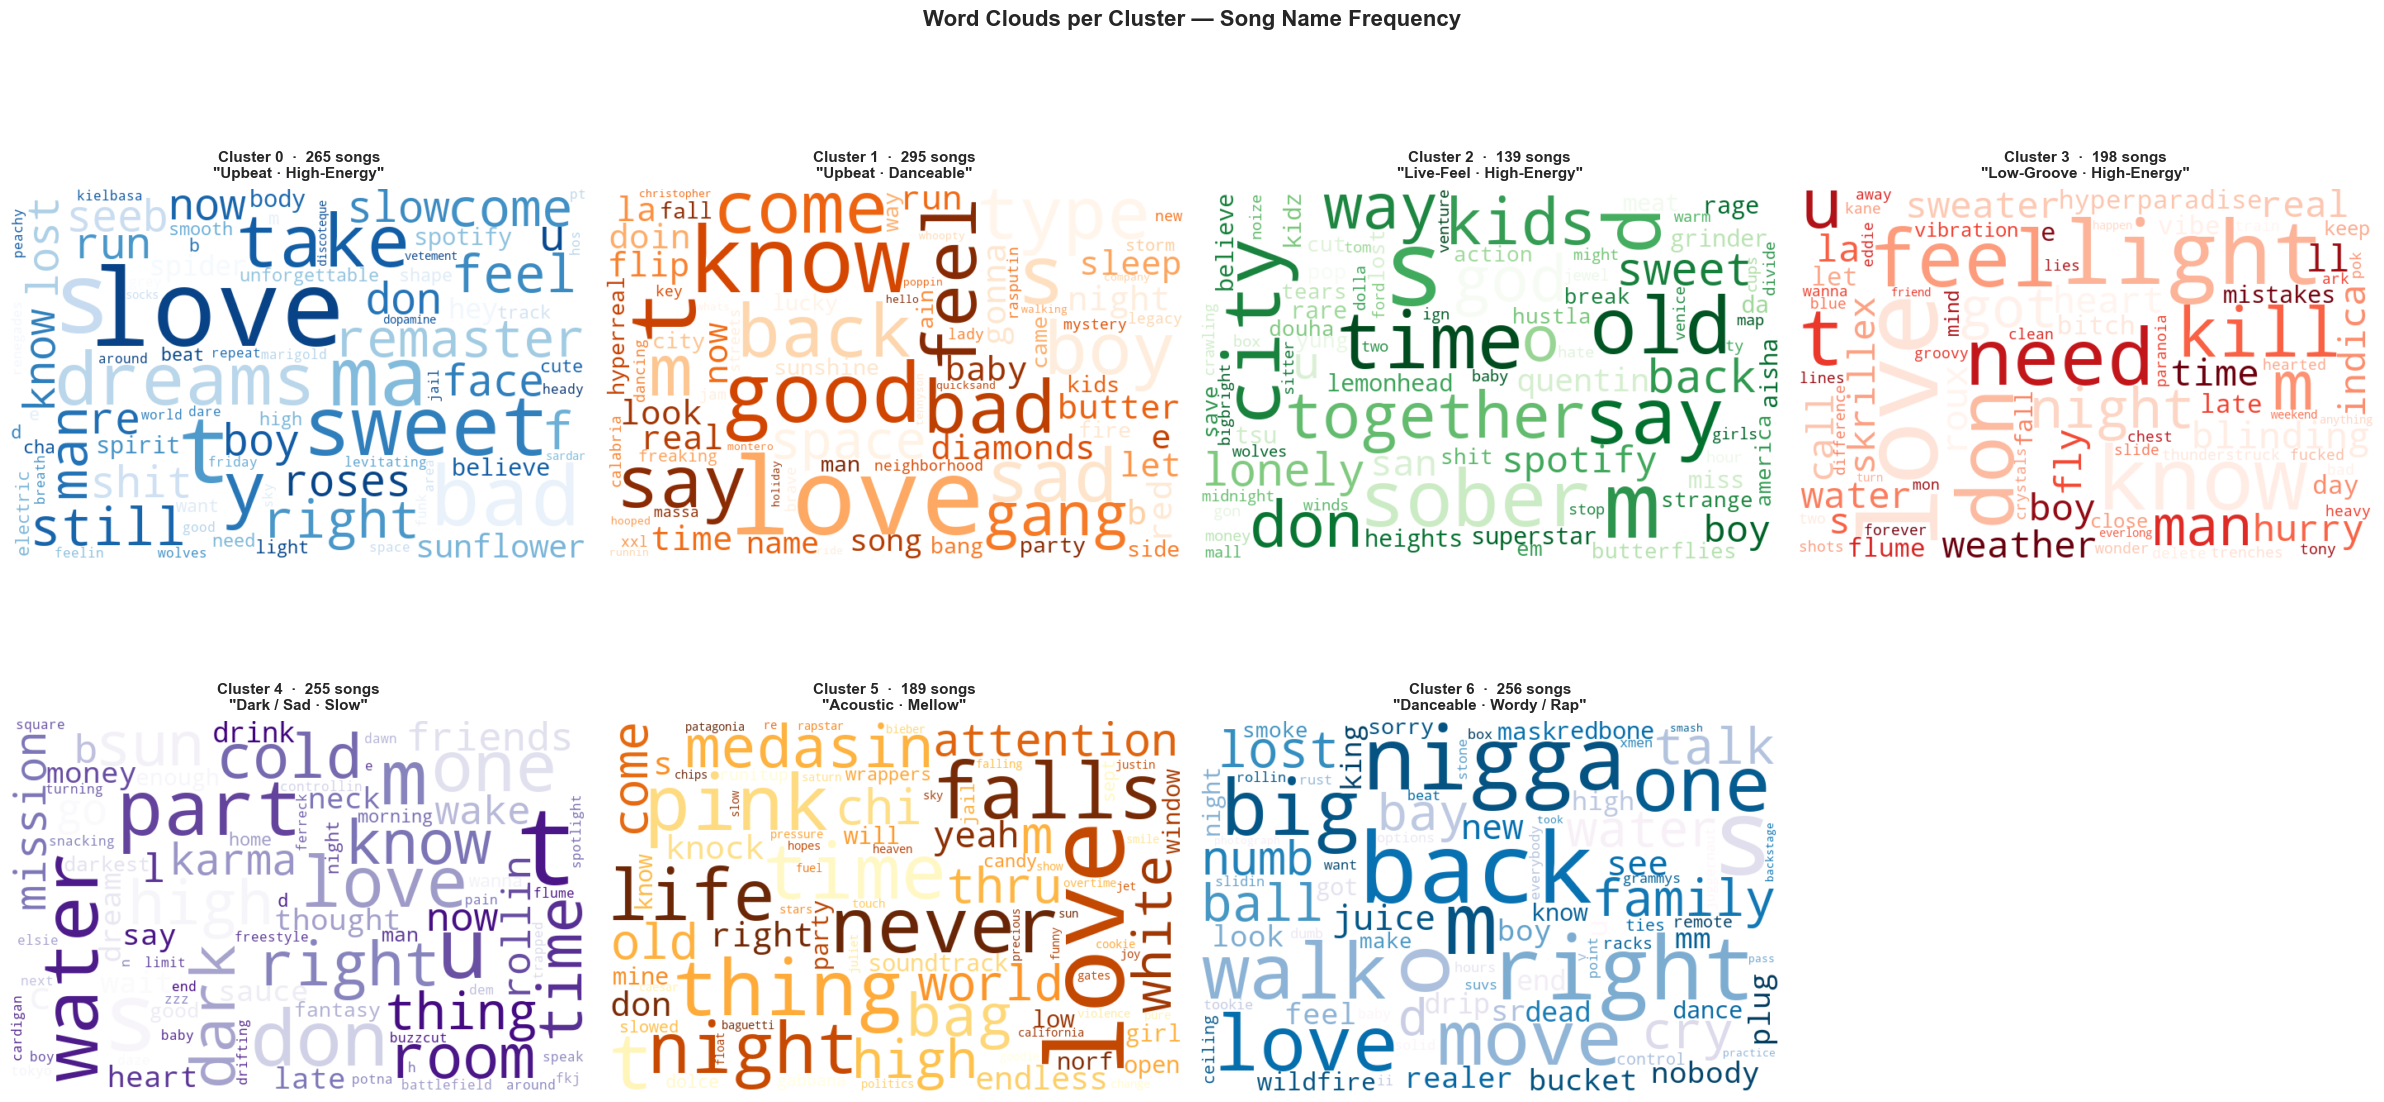

Word clouds saved to: ../data_files/word_clouds.png


In [30]:
import re

try:
    from wordcloud import WordCloud, STOPWORDS
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wordcloud', '--quiet'])
    from wordcloud import WordCloud, STOPWORDS

try:
    from better_profanity import profanity as _prof
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'better-profanity', '--quiet'])
    from better_profanity import profanity as _prof
_prof.load_censor_words()

# One sequential colormap per cluster
CLUSTER_CMAPS = ['Blues', 'Oranges', 'Greens', 'Reds',
                 'Purples', 'YlOrBr', 'PuBu', 'RdPu']

EXTRA_STOPS = {'feat', 'ft', 'remastered', 'remix', 'version', 'edit',
               'radio', 'mix', 'extended', 'original', 'deluxe',
               'bonus', 'live', 'single', 'album', 'instrumental'}
ALL_STOPS   = STOPWORDS | EXTRA_STOPS

# Strip parenthetical content and non-alphabetic characters,
# then remove any word flagged as profanity
_NOISE    = re.compile(r'\(.*?\)|\[.*?\]|\bfeat\.?\b.*|\bft\.?\b.*')
_NONALPHA = re.compile(r'[^a-z\s]')

def clean_name(name):
    s = _NOISE.sub('', str(name).lower())
    s = _NONALPHA.sub(' ', s)
    words = [w for w in s.split() if not _prof.contains_profanity(w)]
    return ' '.join(words)

n_cols = 4
n_rows = (N_CLUSTERS + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, n_rows * 6))
axes = axes.flatten()

for cid in sorted(names_proc['cluster'].unique()):
    ax    = axes[cid]
    songs = names_proc.loc[names_proc['cluster'] == cid, 'songName'].dropna()
    text  = ' '.join(songs.apply(clean_name).tolist())

    if not text.strip():
        ax.text(0.5, 0.5, 'No song names available',
                ha='center', va='center', fontsize=12)
        ax.axis('off')
        continue

    wc = WordCloud(
        width=700, height=450,
        background_color='white',
        colormap=CLUSTER_CMAPS[cid % len(CLUSTER_CMAPS)],
        max_words=80,
        stopwords=ALL_STOPS,
        collocations=False,
        min_font_size=9,
        max_font_size=130,
        prefer_horizontal=0.85
    ).generate(text)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    theme = FINAL_THEMES.get(cid, f'Cluster {cid}')
    ax.set_title(
        f'Cluster {cid}  ·  {len(songs):,} songs\n"{theme}"',
        fontsize=11, fontweight='bold', pad=8
    )

for j in range(N_CLUSTERS, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Word Clouds per Cluster — Song Name Frequency',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data_files/word_clouds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Word clouds saved to: ../data_files/word_clouds.png')

## 14. Per-Cluster Playlist CSVs

Export each cluster as its own CSV file so you can browse the song list for every playlist independently. Files are written to `data_files/playlists/` and named `cluster_<id>_<theme>.csv`.

In [ ]:
import os

PLAYLISTS_DIR = '../data_files/playlists'
os.makedirs(PLAYLISTS_DIR, exist_ok=True)

_safe = lambda s: re.sub(r'[^\w\s-]', '', s).strip().replace(' ', '_').replace('/', '_')
EXPORT_COLS = ['id', 'songName', 'cluster'] + CONTINUOUS_COLS + CATEGORICAL_COLS

print(f"Saving {N_CLUSTERS} playlist CSVs to {PLAYLISTS_DIR}/\n")
for cid in sorted(df['cluster'].unique()):
    theme     = FINAL_THEMES.get(cid, f'Cluster_{cid}')
    filename  = f'cluster_{cid}_{_safe(theme)}.csv'
    filepath  = os.path.join(PLAYLISTS_DIR, filename)
    cluster_df = df.loc[df['cluster'] == cid, EXPORT_COLS].copy()
    cluster_df.to_csv(filepath, index=False)
    print(f'  Cluster {cid}  {len(cluster_df):>4,} songs  →  {filename}')

print(f'\nDone. Browse individual playlists in: {PLAYLISTS_DIR}/')